In [1]:
import torch
print(torch.__version__, torch.cuda.is_available())

!pip install -q 'git+https://github.com/facebookresearch/detectron2.git'
!pip install -q 'git+https://github.com/PatBall1/detectree2.git'

2.11.0+cu128 True
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 13.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 76.9 MB/s eta 0:00:00


In [2]:
import torch, detectron2, detectree2
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())
print("detectron2 OK, detectree2 OK")

torch 2.11.0+cu128 | cuda True
detectron2 OK, detectree2 OK


In [8]:
from google.colab import drive
drive.mount('/content/drive')
!ls /content/drive/MyDrive | grep -i arbor
!ls -la /content/drive/MyDrive/arboris


Mounted at /content/drive
arboris
total 14941
drwx------  6 root root     4096 Sep 19 15:29 .
drwx------ 23 root root     4096 Sep 21 13:07 ..
-rw-------  1 root root 11528234 Sep 19 16:00 arboris_training.csv
drwx------  2 root root     4096 Sep 20 17:41 data
-rw-------  1 root root  3745773 Sep 19 15:29 gedi_l4a_anamalai.csv
drwx------  2 root root     4096 Sep 20 17:41 models
drwx------  2 root root     4096 Sep 20 18:10 tiles
drwx------  2 root root     4096 Sep 20 18:10 train_outputs


In [15]:
from google.colab import drive; drive.mount('/content/drive')
import geopandas as gpd, os
from detectree2.preprocessing.tiling import tile_data
from detectree2.models.train import setup_cfg
from detectree2.models.predict import predict_on_data
from detectree2.models.outputs import project_to_geojson, stitch_crowns, clean_crowns
from detectron2.engine import DefaultPredictor

ROOT = "/content/drive/MyDrive/arboris"
IMG  = f"{ROOT}/data/raw/demo8.tif"          # held-out tile 8
TRUTH= f"{ROOT}/data/raw/demo8.geojson"  # its ground-truth crowns

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import rasterio
truth = gpd.read_file(TRUTH)
with rasterio.open(IMG) as s: print("img:", s.crs, s.bounds)
print("truth:", truth.crs, truth.total_bounds, len(truth), "crowns")

img: EPSG:32611 BoundingBox(left=316835.958, bottom=4092000.054, right=316876.049, top=4092039.946)
truth: EPSG:32611 [ 316838.563915 4092001.94887   316876.049    4092038.25059 ] 8 crowns


In [52]:
!rm -rf /content/drive/MyDrive/arboris/pred_*

In [53]:
def run(weights, tag):
    out = f"{ROOT}/pred_{tag}/"
    tile_data(IMG, out, buffer=0, tile_width=41, tile_height=41,full_coverage=True, dtype_bool=True)  # MUST match training tiling
    cfg = setup_cfg(update_model=weights)
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.05   # keep low; filter later
    predict_on_data(out, out_folder=out+"predictions/", predictor=DefaultPredictor(cfg))
    project_to_geojson(out, out+"predictions/", out+"predictions_geo/")  # pixel coords → map coords
    crowns = stitch_crowns(out+"predictions_geo/", 1)   # merge tiles back into one layer
    crowns = clean_crowns(crowns, 0.6, confidence=0)    # drop duplicate crowns in buffer overlaps (IoU>0.6)
    return crowns

ft   = run(f"{ROOT}/train_outputs/model_1.pth", "ft")
base = run(f"{ROOT}/models/pretrained.pth", "base")

  0%|          | 0/1 [00:00<?, ?it/s]

Stitching crowns: 100%|██████████| 1/1 [00:00<00:00, 23.64file/s]


clean_crowns: Performing spatial join...


clean_crowns: Processing candidate pairs: 100%|██████████| 244/244 [00:00<00:00, 3121.36it/s]


  0%|          | 0/1 [00:00<?, ?it/s]

Stitching crowns: 100%|██████████| 1/1 [00:00<00:00, 40.67file/s]


clean_crowns: Performing spatial join...


clean_crowns: Processing candidate pairs: 100%|██████████| 174/174 [00:00<00:00, 3637.53it/s]


In [38]:
!grep -n "range\|arange" $(python -c "import detectree2.preprocessing.tiling as t; print(t.__file__)")

355:                i for i in list(range(1, data.count + 1)) if i not in [i + 1 for i in ignore_bands_indices]
599:                for minx in np.arange(start_x, end_x, tile_width)
600:                for miny in np.arange(start_y, end_y, tile_height)
605:                    for minx in np.arange(start_x + tile_width // 2, end_x - tile_width // 2, tile_width)
606:                    for miny in np.arange(start_y + tile_height // 2, end_y - tile_height // 2, tile_height)
636:        for row in range(required_tiles_y):
651:            for col in range(required_intersection_tiles_x):
697:            for band_idx in range(1, src.count + 1):
713:                for row_off in tqdm(range(0, height, chunk_height),
787:        for band_idx in range(1, src.count + 1):
809:            for band_idx in range(1, src.count + 1) if mode == "ms" else range(1, 4):
834:        for band_idx in range(1, len(band_aggregates) + 1) if mode == "ms" else range(1, 4):
1077:        # 4. Compute a robust range (

In [39]:
!sed -n '580,612p' $(python -c "import detectree2.preprocessing.tiling as t; print(t.__file__)")

            Edge tiles may extend beyond the raster bounds; rasterio will fill out-of-bounds
            areas with nodata. Useful for prediction to ensure no pixels are missed.
    """
    coordinates: List[Tuple[int, int]] = []
    if tile_placement == "grid":
        with rasterio.open(img_path) as data:
            if full_coverage:
                start_x = int(math.ceil(data.bounds[0]))
                end_x = int(math.ceil(data.bounds[2]))
                start_y = int(math.ceil(data.bounds[1]))
                end_y = int(math.ceil(data.bounds[3]))
            else:
                start_x = int(math.ceil(data.bounds[0])) + buffer
                end_x = int(data.bounds[2] - tile_width - buffer)
                start_y = int(math.ceil(data.bounds[1])) + buffer
                end_y = int(data.bounds[3] - tile_height - buffer)

            grid_coords = [
                (int(minx), int(miny))
                for minx in np.arange(start_x, end_x, tile_width)
                for 

In [40]:
import inspect; print("full_coverage" in str(inspect.signature(tile_data)))

True


In [27]:
print(len(ft), len(base), "predicted crowns")

4 3 predicted crowns


In [45]:
truth = gpd.read_file(TRUTH).to_crs(ft.crs)

def score(pred, thr):
    p = pred[pred.Confidence_score >= thr].reset_index(drop=True)
    matched, used = 0, set()
    for g in p.geometry:                              # greedy 1-to-1 match
        best, bj = 0, None
        for j, t in truth.geometry.items():
            if j in used or not g.intersects(t): continue
            iou = g.intersection(t).area / g.union(t).area
            if iou > best: best, bj = iou, j
        if best >= 0.5: matched += 1; used.add(bj)
    P, R = matched/max(len(p),1), matched/len(truth)
    return dict(n_pred=len(p), n_true=len(truth), P=round(P,3), R=round(R,3), F1=round(2*P*R/max(P+R,1e-9),3))

for thr in [0.3, 0.5, 0.7]:
    print(thr, "FT:", score(ft, thr), "| BASE:", score(base, thr))

0.3 FT: {'n_pred': 6, 'n_true': 8, 'P': 0.5, 'R': 0.375, 'F1': 0.429} | BASE: {'n_pred': 7, 'n_true': 8, 'P': 0.571, 'R': 0.5, 'F1': 0.533}
0.5 FT: {'n_pred': 4, 'n_true': 8, 'P': 0.5, 'R': 0.25, 'F1': 0.333} | BASE: {'n_pred': 6, 'n_true': 8, 'P': 0.667, 'R': 0.5, 'F1': 0.571}
0.7 FT: {'n_pred': 3, 'n_true': 8, 'P': 0.667, 'R': 0.25, 'F1': 0.364} | BASE: {'n_pred': 2, 'n_true': 8, 'P': 1.0, 'R': 0.25, 'F1': 0.4}


<Axes: >

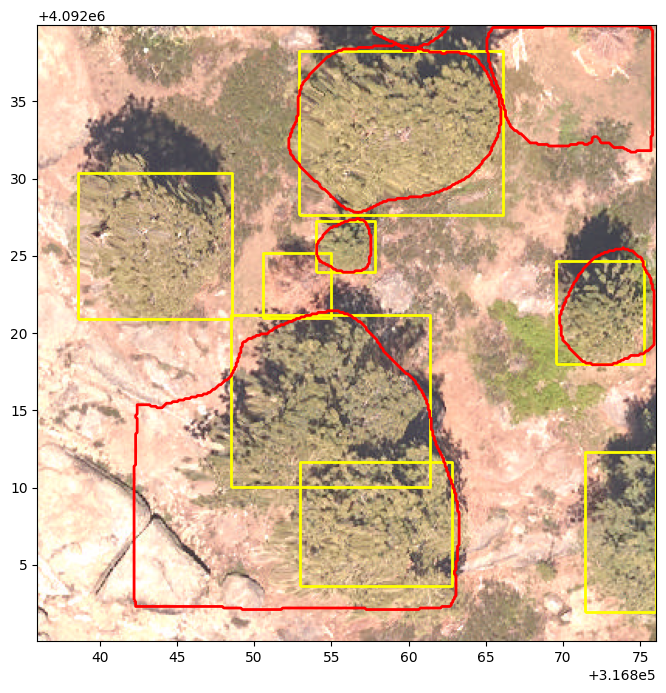

In [46]:
import matplotlib.pyplot as plt, rasterio.plot
fig, ax = plt.subplots(figsize=(8,8))
with rasterio.open(IMG) as s: rasterio.plot.show(s, ax=ax)
truth.boundary.plot(ax=ax, color="yellow", lw=2)
ft[ft.Confidence_score>=0.3].boundary.plot(ax=ax, color="red", lw=2)

In [48]:
import rasterio, xml.etree.ElementTree as ET
from shapely.geometry import box

def xml_truth(img, xml):
    with rasterio.open(img) as s: T, crs = s.transform, s.crs
    g = []
    for o in ET.parse(xml).findall("object"):
        b = o.find("bndbox"); x0,y0,x1,y1 = [float(b.find(k).text) for k in ("xmin","ymin","xmax","ymax")]
        (a,d),(c,e) = T*(x0,y0), T*(x1,y1); g.append(box(a,e,c,d))
    return gpd.GeoDataFrame(geometry=g, crs=crs)

tot = dict(m=0, p=0, t=0)
for t in [8, 9, 10]:
    IMG   = f"{ROOT}/data/raw/demo{t}.tif"
    truth = xml_truth(IMG, f"{ROOT}/data/raw/demo{t}.xml")
    pred  = run(f"{ROOT}/models/pretrained.pth", f"base{t}")
    s = score(pred, 0.5); print(t, s)
    tot["m"] += round(s["P"]*s["n_pred"]); tot["p"] += s["n_pred"]; tot["t"] += s["n_true"]

P, R = tot["m"]/tot["p"], tot["m"]/tot["t"]
print("POOLED  P", round(P,3), "R", round(R,3), "F1", round(2*P*R/(P+R),3), "| crowns:", tot["t"])

  0%|          | 0/1 [00:00<?, ?it/s]

Stitching crowns: 100%|██████████| 1/1 [00:00<00:00, 67.49file/s]


clean_crowns: Performing spatial join...


clean_crowns: Processing candidate pairs: 100%|██████████| 4/4 [00:00<00:00, 1462.58it/s]


8 {'n_pred': 6, 'n_true': 8, 'P': 0.667, 'R': 0.5, 'F1': 0.571}


...

  0%|          | 0/1 [00:00<?, ?it/s]

Stitching crowns: 100%|██████████| 1/1 [00:00<00:00, 59.50file/s]


clean_crowns: Performing spatial join...


clean_crowns: Processing candidate pairs: 100%|██████████| 8/8 [00:00<00:00, 2583.69it/s]

10 {'n_pred': 10, 'n_true': 56, 'P': 0.8, 'R': 0.143, 'F1': 0.242}
POOLED  P 0.781 R 0.234 F1 0.36 | crowns: 107


In [50]:
preds, truths = {}, {}
BASE = f"{ROOT}/models/pretrained.pth"
for t in [8, 9, 10]:
    IMG = f"{ROOT}/data/raw/demo{t}.tif"
    truths[t] = xml_truth(IMG, f"{ROOT}/data/raw/demo{t}.xml")
    preds[t]  = run(BASE, f"base{t}")

  0%|          | 0/1 [00:00<?, ?it/s]

Stitching crowns: 100%|██████████| 1/1 [00:00<00:00, 62.00file/s]


clean_crowns: Performing spatial join...


clean_crowns: Processing candidate pairs: 100%|██████████| 4/4 [00:00<00:00, 1863.72it/s]


  0%|          | 0/1 [00:00<?, ?it/s]

...

clean_crowns: Processing candidate pairs: 100%|██████████| 38/38 [00:00<00:00, 2456.06it/s]


  0%|          | 0/1 [00:00<?, ?it/s]

Stitching crowns: 100%|██████████| 1/1 [00:00<00:00, 26.73file/s]


clean_crowns: Performing spatial join...


clean_crowns: Processing candidate pairs: 100%|██████████| 8/8 [00:00<00:00, 1367.56it/s]


In [51]:
def score(pred, truth, thr, iou):
    p = pred[pred.Confidence_score >= thr].reset_index(drop=True)
    p = p.set_geometry(p.envelope)
    used, m = set(), 0
    for g in p.geometry:
        best, bj = 0, None
        for j, t in truth.geometry.items():
            if j in used or not g.intersects(t): continue
            v = g.intersection(t).area / g.union(t).area
            if v > best: best, bj = v, j
        if best >= iou: m += 1; used.add(bj)
    return m, len(p), len(truth)

def pooled(thr, iou):
    M = P = T = 0
    for t in [8, 9, 10]:
        m, p, n = score(preds[t], truths[t], thr, iou); M += m; P += p; T += n
    pr, rc = M/max(P,1), M/T
    return f"thr={thr} iou={iou} | found {M}/{T} trees, drew {P} boxes | P={pr:.2f} R={rc:.2f} F1={2*pr*rc/max(pr+rc,1e-9):.2f}"

print(pooled(0.5, 0.5))
print(pooled(0.5, 0.4))

thr=0.5 iou=0.5 | found 24/107 trees, drew 32 boxes | P=0.75 R=0.22 F1=0.35
thr=0.5 iou=0.4 | found 25/107 trees, drew 32 boxes | P=0.78 R=0.23 F1=0.36


In [54]:
preds, truths = {}, {}
for t in range(1, 11):
    IMG = f"{ROOT}/data/raw/demo{t}.tif"
    truths[t] = xml_truth(IMG, f"{ROOT}/data/raw/demo{t}.xml")
    preds[t]  = run(BASE, f"base{t}")

  0%|          | 0/1 [00:00<?, ?it/s]

Stitching crowns: 100%|██████████| 1/1 [00:00<00:00, 47.02file/s]


clean_crowns: Performing spatial join...


clean_crowns: Processing candidate pairs: 100%|██████████| 118/118 [00:00<00:00, 4493.67it/s]


  0%|          | 0/1 [00:00<?, ?it/s]

...

clean_crowns: Processing candidate pairs: 100%|██████████| 194/194 [00:00<00:00, 5768.43it/s]


  0%|          | 0/1 [00:00<?, ?it/s]

Stitching crowns: 100%|██████████| 1/1 [00:00<00:00, 51.27file/s]


clean_crowns: Performing spatial join...


clean_crowns: Processing candidate pairs: 100%|██████████| 174/174 [00:00<00:00, 4935.71it/s]


In [57]:
thrs = [0.1, 0.2, 0.3, 0.4, 0.5]
def f1(thr, tiles):
    M = P = T = 0
    for t in tiles:
        m, p, n = score(preds[t], truths[t], thr, 0.4); M += m; P += p; T += n
    pr, rc = M/max(P,1), M/T
    return 2*pr*rc/max(pr+rc,1e-9)

BEST_THR = max(thrs, key=lambda th: f1(th, range(1, 8)))   # chosen on images 1–7 only
print("BEST_THR =", BEST_THR)
print("TEST:", pooled(BEST_THR, 0.4, [8, 9, 10]))


BEST_THR = 0.1
TEST: thr=0.1 | found 42/107, drew 71 | P=0.59 R=0.39 F1=0.47


In [56]:
print("TEST:", pooled(BEST_THR, 0.4, [8, 9, 10]))   # replace BEST_THR with the threshold that won in Step 3

NameError: name 'BEST_THR' is not defined

In [58]:
!mkdir -p /content/drive/MyDrive/arboris/outputs
demo = preds[8][preds[8].Confidence_score >= BEST_THR]
demo.to_file(f"{ROOT}/outputs/demo8_crowns.geojson", driver="GeoJSON")
print(len(demo), "predicted crowns vs", len(truths[8]), "true")

11 predicted crowns vs 8 true
